<a href="https://colab.research.google.com/github/MuxuZhao/math/blob/main/Lie_Algebra_Techniques_for_Transverse_Ising_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lie Algebra Techniques for 1D Ising Model

In [ ]:
import numpy as np
import pylab as plt
import scipy
import scipy.linalg

### Part I: Creating Pauli Strings

In this part, we introduce the construction of commutators between two Pauli strings. The Pauli string $P$, defined as a product of Pauli matrices, and can be represented as follows:



$$a = V_{i_1} \dots V_{i_k},$$



where $$V_i \in \{X_i, Y_i, Z_i\}.$$

To analyze the commutators of two Pauli strings, note that there are two possible outcomes for their commutator:

$$
[a,b] = \begin{cases}
0 & \text{if } ab=ba \\
2ab & \text{if } ab = -ba\\
\end{cases}
$$



The set of Pauli strings can be identified as a groupoid. The Pauli strings denote the vertices, and the nonzero commutators denote the edges. The arrows between two vertices are invertible since



$$[a,[a,b]] \propto b.$$

Explicitly, two Pauli strings (vertices) are connected by an arrow if their commutator is nonzero, which can be represented by:

$$a \to ab$$


if $[a, b] = 2ab$.



Having explored the groupoid structure, we now turn to the Hamiltonian for the transverse Ising model:

$$H = J \sum_j Z_jZ_{J+1} + \mu \sum_j X_j$$

In this Hamiltonian, $J$ describes the coupling between nearest-neighbor sites, while $\mu$ determines the strength of the external magnetic field. This leads us to define the initial set of Pauli strings as follows:



$$S = \{Z_jZ_{j+1}\}_{j=1}^{n-1} \cup \{X_j\}_{j=1}^n$$



Based on these generators, we can represent the Pauli words (strings) as follows.



$$w = (w_1, \dots, w_n),$$



Here, $w_j \in \{1,X,Y,Z\}$. For example, the Pauli string $Z_1Z_2$ can be written as:



$$(Z,Z,1, \dots, 1)$$



Our goal is to write the set of Pauli words that can be generated by repeatedly applying the commutator. In other words, we want to determine the transitive hull of the groupoid.

Write a program to generate all the Pauli strings (words) for $n=5$ qubits interacting based on the transverse Ising model Hamiltonian.

**Answer (start):**

---



In [ ]:
# encoding Pauli matrices
pauli_matrices = {0: 'I', 1: 'X', 2: 'Y', 3: 'Z'}

# generating Pauli strings for n qubits
def generate_pauli_strings(n):
  result = [()]
  for _ in range(n):
    result1 = []
    for c in (0,1,2,3):
      for r in result:
        result1.append((c,) + r)
    result = result1
  return result

n = 5
pauli_string_n5 = generate_pauli_strings(5)

# check
# print(len(pauli_string_n5))
print(pauli_string_n5[:10])

def to_str(tuple):
  parts = []
  for i, c in enumerate(tuple):
    if c != 0: # ignore I
      parts.append(f"{pauli_matrices[c]}{i+1}")
  return " ".join(parts) if parts else "I"*len(tuple)
# print(to_str((3,3,0,0,0)))

[(0, 0, 0, 0, 0), (0, 0, 0, 0, 1), (0, 0, 0, 0, 2), (0, 0, 0, 0, 3), (0, 0, 0, 1, 0), (0, 0, 0, 1, 1), (0, 0, 0, 1, 2), (0, 0, 0, 1, 3), (0, 0, 0, 2, 0), (0, 0, 0, 2, 1)]




---
**End**


What is the pattern of the Pauli strings? Write a program to count the number of generated Pauli strings (words) for $n$ qubits interacting according to the transverse Ising model Hamiltonian. Plot the number of generated Pauli strings versus the number of qubits for $n = 1$ to $n=10$.

**Answer (start):**

---

n	size
1	1	 1
2	6	 6
3	15	 15
4	28	 28
5	45	 45
6	66	 66
7	91	 91
8	120	 120
9	153	 153
10	190	 190


Text(0.5, 1.0, 'pattern of pauli string')

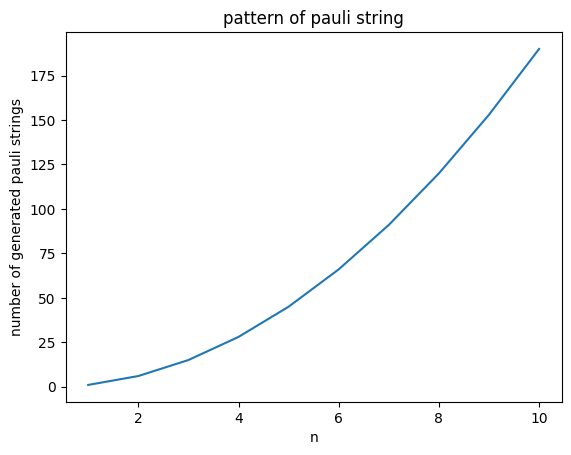

In [ ]:
I, X, Y, Z = 0, 1, 2, 3
mul_table = [[0,1,2,3],   # I * (I,X,Y,Z) = (I,X,Y,Z)
        [1,0,3,2],   # X * (I,X,Y,Z) = (X,I,Z,Y)
        [2,3,0,1],   # Y * (I,X,Y,Z) = (Y,Z,I,X)
        [3,2,1,0]]   # Z * (I,X,Y,Z) = (Z,Y,X,I)
def multiply(p,q): # p,q two pauli strings multiply each other
  return tuple(mul_table[p[i]][q[i]] for i in range(len(p)))
  # ex: p=Z1Z2, q=X1, p*q=Z1Z2 * X1 = Y1Z2 = (3,3,0)*(1,0,0)=(2,3,0)=Y1Z2

def anticommute(p,q):
  cnt = 0
  for i in range(len(p)):
    a, b = p[i], q[i]
    if a != I and b != I and a != b: # if both not I and not equal, count
      cnt += 1
  return (cnt % 2) == 1 # count is odd -> anticommute -> new pauli string

def count_pauli_string(n):
  pauli_strings = set()
  for j in range(n-1): # add Z_j Z_{j+1}
    lst = [I] * n
    lst[j] = Z
    lst[j+1] = Z
    pauli_strings.add(tuple(lst))
  for j in range(n): # add X_j
    lst = [I] * n
    lst[j] = X
    pauli_strings.add(tuple(lst))

  # add new pauli string, BFS to check if there's repetition
  generated_strings = set(pauli_strings)
  queue = list(pauli_strings)
  while queue:
    a = queue.pop()
    for b in list(generated_strings):
      if anticommute(a, b):
        c = multiply(a, b)
        if c not in generated_strings:
          generated_strings.add(c)
          queue.append(c)
  return len(generated_strings)


# count from n=1 to n=10
sizes = []
ns = list(range(1,11))
print(f"n\tsize")
for n in ns:
  sz = count_pauli_string(n)
  sizes.append(sz)
  print(f"{n}\t{sz}\t {n*(2*n-1)}")

# plot
plt.plot(ns, sizes)
plt.xlabel('n')
plt.ylabel('number of generated pauli strings')
plt.title("pattern of pauli string")




---
**End**

### Part II: The Ripple Effect

**In** the second section, Now, we add a new Pauli string to the initial set of Pauli strings (words):

$$S_1 = S \cup \{X_1X_2\}.$$

By adding this ripple effect, we generate a bigger Lie algebra. Write a program to calculate the number of the generated Pauli strings of $S_1$ for $n=1$ to $n=7$, and compare it to the number of Pauli strings for $S$ in the previous part.

Furthermore, plot the number of generated Pauli strings for $n=1$ to $n=7$ for both $S$ and $S_1$ sets. You may use the log scale to represent the data.

**Compare your results with the mathematical results in the paper.**


**Answer (start):**

---

n	size
1	1
2	7
3	30
4	126
5	510
6	2046
7	8190


Text(0.5, 1.0, 'pattern of pauli string with or without ripple effect')

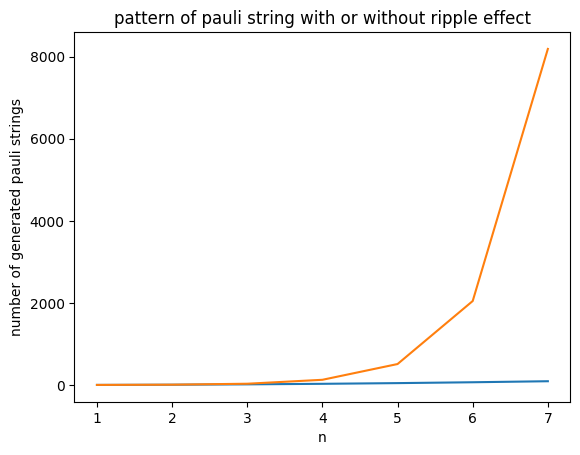

In [ ]:
def count_pauli_string_new(n):
  pauli_strings = set()
  for j in range(n-1): # add Z_j Z_{j+1}
    lst = [I] * n
    lst[j] = Z
    lst[j+1] = Z
    pauli_strings.add(tuple(lst))
  for j in range(n): # add X_j
    lst = [I] * n
    lst[j] = X
    pauli_strings.add(tuple(lst))
  if n >= 2: # add X_1 X2
    lst = [I] * n
    lst[0] = X
    lst[1] = X
    pauli_strings.add(tuple(lst))

  # add new pauli string, BFS to check if there's repetition
  generated_strings = set(pauli_strings)
  queue = list(pauli_strings)
  while queue:
    a = queue.pop()
    for b in list(generated_strings):
      if anticommute(a, b):
        c = multiply(a, b)
        if c not in generated_strings:
          generated_strings.add(c)
          queue.append(c)
  return len(generated_strings)

# count from n=1 to n=7
sizes1 = []
ns1 = list(range(1,8))
print(f"n\tsize")
for n in ns1:
  sz = count_pauli_string_new(n)
  sizes1.append(sz)
  print(f"{n}\t{sz}")

# plot
# plt.plot(ns1, sizes1)
# plt.xlabel('n')
# plt.ylabel('number of generated pauli strings')
# plt.title("pattern of pauli string with new S")


# data summary and comparison
n = list(range(1, 8))
sizes_S = [1, 6, 15, 28, 45, 66, 91]
sizes_S1 = [1, 7, 30, 126, 510, 2046, 8190]
plt.plot(n, sizes_S, label='S')
plt.plot(n, sizes_S1, label='S1')
# plt.yscale('log')
plt.xlabel('n')
plt.ylabel('number of generated pauli strings')
plt.title("pattern of pauli string with or without ripple effect")


---
**End**

### Part III: The Distance Between Pauli Words

In this section, we continue by considering the set of initial generators $S_1$. We define the distance between Pauli strings $a$ and $b$ as the minimum number of Pauli strings (words) between $a$ and $b$ in the groupoid picture. For $n=5$, starting from the Pauli word $Z_1Z_2$, write a program to calculate the distance of all Pauli strings to $Z_1Z_2$, and classify the number of Pauli strings based on their distance $m$, where $1 < m < n$.

**Answer (start):**

---

In [ ]:
# generate pauli string with S1
def generate_pauli_string_new(n):
  pauli_strings = set()
  for j in range(n-1): # add Z_j Z_{j+1}
    lst = [I] * n
    lst[j] = Z
    lst[j+1] = Z
    pauli_strings.add(tuple(lst))
  for j in range(n): # add X_j
    lst = [I] * n
    lst[j] = X
    pauli_strings.add(tuple(lst))
  if n >= 2: # add X_1 X2
    lst = [I] * n
    lst[0] = X
    lst[1] = X
    pauli_strings.add(tuple(lst))

  # add new pauli string, BFS to check if there's repetition
  generated_strings = set(pauli_strings)
  queue = list(pauli_strings)
  while queue:
    a = queue.pop()
    for b in list(generated_strings):
      if anticommute(a, b):
        c = multiply(a, b)
        if c not in generated_strings:
          generated_strings.add(c)
          queue.append(c)
  return generated_strings


# calculate distances, using bfs
def distances(source, vertices):
  from collections import deque
  dist = {source: 0}
  q = deque([source])
  while q:
    a = q.popleft()
    for b in vertices:
      if b not in dist and anticommute(a, b):
        dist[b] = dist[a] + 1
        q.append(b)
  return dist

# main
n = 5
pauli_strings_s1 = generate_pauli_string_new(n)
print(f"Total Pauli strings in S1: {len(pauli_strings_s1)}")
source = (Z, Z, I, I, I)  # (3,3,0,0,0)
if source not in pauli_strings_s1:
  raise ValueError("Source Z1Z2 not in closure? Check generation.")
# all vertices
vertices = list(pauli_strings_s1)
dist_dict = distances(source, vertices)
# count
dist_counts = {}
for v, d in dist_dict.items():
  if d == 0:
    continue
  dist_counts[d] = dist_counts.get(d, 0) + 1
print("\nDistance distribution from Z1Z2:")
for d in sorted(dist_counts.keys()):
  print(f"  distance {d}: {dist_counts[d]} Pauli strings")

# 1 < m < 5
print("\nFor 1 < m < 5 (m=2,3,4):")
for m in (2,3,4):
  count = dist_counts.get(m, 0)
  print(f"  m={m}: {count} strings")

Total Pauli strings in S1: 510

Distance distribution from Z1Z2:
  distance 1: 256 Pauli strings
  distance 2: 253 Pauli strings

For 1 < m < 5 (m=2,3,4):
  m=2: 253 strings
  m=3: 0 strings
  m=4: 0 strings


---
**End**

Write a program to calculate the distance between any two given Pauli strings $a$ and $b$:

$$a \to a_1 \to a_2 \to \dots \to b.$$

Also, represent the nodes and edges (commutator) between $a$ and $b$ in a graph.

**Answer (start):**

---

Finding path between Z1 Z2 and X1 X2...
Shortest path distance: 2
Path: Z1 Z2 -> Y1 Y3 -> X1 X2


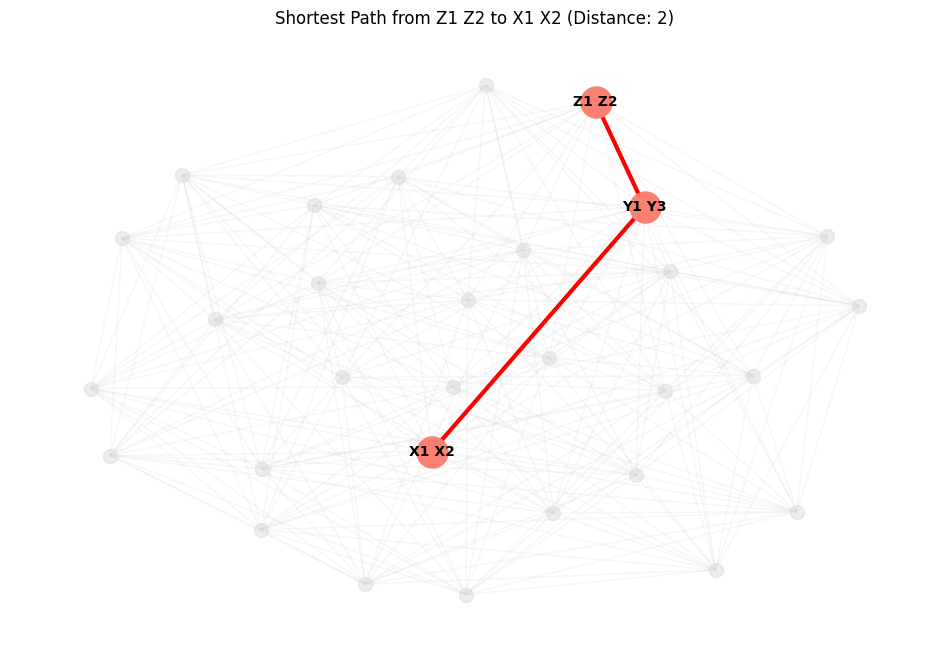

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def shortest_path_between(a, b, vertices):
  if a == b:
    return [a], 0
  queue = deque([a])
  visited = {a: None}
  while queue:
    cur = queue.popleft()
    for nxt in vertices:
      if nxt not in visited and anticommute(cur, nxt):
        visited[nxt] = cur
        if nxt == b:
          path = []
          node = b
          while node is not None:
              path.append(node)
              node = visited[node]
          path.reverse()
          return path, len(path) - 1
        queue.append(nxt)
  return None, -1

def build_graph(vertices):
  G = nx.Graph()
  for v in vertices:
    label = to_str(v)
    G.add_node(label, pauli=v)
  vlist = list(vertices)
  for i in range(len(vlist)):
    for j in range(i+1, len(vlist)):
      if anticommute(vlist[i], vlist[j]):
        G.add_edge(to_str(vlist[i]), to_str(vlist[j]))
  return G

def visualize_path(path, G):
  path_labels = [to_str(node) for node in path]
  path_edges = [(path_labels[i], path_labels[i+1]) for i in range(len(path_labels)-1)]

  plt.figure(figsize=(12, 8))
  pos = nx.spring_layout(G, k=0.3, seed=42)
  nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=100, alpha=0.4)
  nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.2)
  nx.draw_networkx_nodes(G, pos, nodelist=path_labels, node_color='salmon', node_size=500)
  nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3.0)
  labels = {node: node for node in path_labels}
  nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')
  plt.title(f"Shortest Path from {path_labels[0]} to {path_labels[-1]} (Distance: {len(path)-1})")
  plt.axis('off')
  plt.show()


# instance
n_val = 3
pauli_strings_s1 = generate_pauli_string_new(n_val)
vertices = list(pauli_strings_s1)
G = build_graph(vertices)

# Select two Pauli strings to find the distance between
# Z1Z2 -> (3, 3, 0)
# X1X2 -> (1, 1, 0)
a = (3, 3, 0)
b = (1, 1, 0)

if a not in vertices or b not in vertices:
  a, b = vertices[0], vertices[-1]

print(f"Finding path between {to_str(a)} and {to_str(b)}...")

# Calculate the shortest path
path, distance = shortest_path_between(a, b, vertices)

if path:
  print(f"Shortest path distance: {distance}")
  path_str = " -> ".join([to_str(p) for p in path])
  print(f"Path: {path_str}")
  visualize_path(path, G)
else:
  print("No path found between the given Pauli strings.")

---
**End**